# Análisis de sentimientos en textos turísticos mexicanos

Este notebook entrena un modelo de clasificación de sentimientos en español usando el dataset de opiniones turísticas. Se incluyen métricas, visualizaciones, análisis de errores y recomendaciones para mejorar el desempeño del modelo.

In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from datasets import load_dataset, concatenate_datasets, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import gc


/home/andresmtr/miniconda3/envs/PruebaBRM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Carge de datos

In [2]:
raw_data = load_dataset("alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad")
print(raw_data)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 176192
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 75510
    })
})


In [3]:
# Se unen los datos de entrenamiento y test en uno solo para tener mas información

full_data = concatenate_datasets([raw_data["train"], raw_data["test"]])

In [4]:
# Visualizar los primeros ejemplos como si fuera pandas
print("\nPrimeros 5 registros del dataset:")
print(pd.DataFrame(full_data[:5]))


Primeros 5 registros del dataset:
                                                text  label
0  el mejor lugar para comer sushi. excelente lug...      5
1  vista hermosa!. me sorprendió la maravillosa v...      5
2  desastroso. buenas noches,  ante todo explicar...      1
3  todo bien excepto que se niegan a dar vasos de...      3
4  el mejor zoologico de méxico. el ambiente es m...      5


/tmp/ipykernel_6682/1668420484.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_full, x="label", palette="Blues")


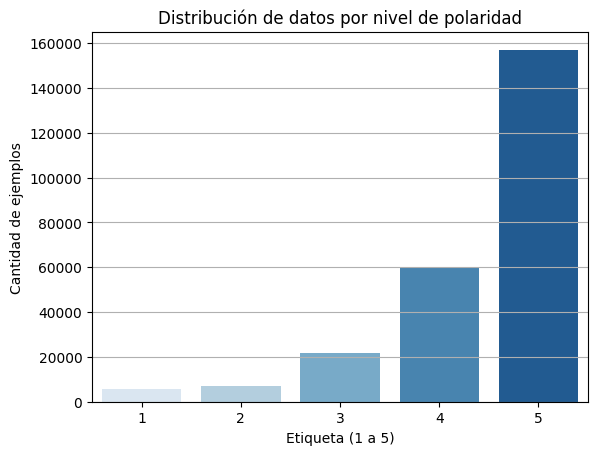

In [5]:
# Convertir a DataFrame para graficar
df_full = pd.DataFrame(full_data)

# Gráfico de barras por etiqueta
sns.countplot(data=df_full, x="label", palette="Blues")

# Personalización del gráfico
plt.title("Distribución de datos por nivel de polaridad")
plt.xlabel("Etiqueta (1 a 5)")
plt.ylabel("Cantidad de ejemplos")
plt.grid(axis="y")
plt.show()

In [6]:
label_counts = df_full['label'].value_counts().sort_index()

# Crear la tabla
tabla_resumen = pd.DataFrame({
    'Etiqueta': label_counts.index,
    'Cantidad de ejemplos': label_counts.values
})

# Mostrar la tabla
tabla_resumen

,Etiqueta,Cantidad de ejemplos
0,1,5772
1,2,6952
2,3,21656
3,4,60227
4,5,157095


In [7]:
del df_full
gc.collect()

170

In [8]:
# Ajustar etiquetas de 1-5 a 0-4
def adjust_labels(example):
    example["label"] = example["label"] - 1
    return example

# Preparar los datos para la tokenizacion

In [9]:
tokenizer = AutoTokenizer.from_pretrained("PlanTL-GOB-ES/roberta-base-bne")

In [10]:
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

In [11]:
# Preprocesamiento
processed = full_data.map(adjust_labels)
processed = processed.map(tokenize, batched=True)
processed.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


In [12]:
# Aplicar oversampling para balancear clases
labels = [x for x in processed['label']]
counts = Counter(labels)
max_count = max(counts.values())

# Definir cuántos ejemplos extra deseas por clase (controlado)
extra_per_class = {
    0: 40000,
    1: 35000,
    2: 20000,
    3: 10000
}

balanced_data = []

# Agrupar registros por clase
for label in range(5):
    class_samples = [processed[i] for i in range(len(processed)) if processed[i]['label'] == label]
    
    # Agregar los originales
    balanced_data.extend(class_samples)

    # Oversample solo si se especifica
    if label in extra_per_class:
        extra_count = extra_per_class[label]
        sampled = random.choices(class_samples, k=extra_count)  # random.choices en vez de np.random.choice
        balanced_data.extend(sampled)

# Crear el dataset balanceado
balanced_dataset = Dataset.from_list(balanced_data)

In [13]:
# Convertir a DataFrame para graficar
df_full = pd.DataFrame(balanced_dataset)

label_counts = df_full['label'].value_counts().sort_index()

# Crear la tabla
tabla_resumen = pd.DataFrame({
    'Etiqueta': label_counts.index,
    'Cantidad de ejemplos': label_counts.values
})

# Mostrar la tabla
tabla_resumen

,Etiqueta,Cantidad de ejemplos
0,0,45772
1,1,41952
2,2,41656
3,3,70227
4,4,157095


In [14]:
del df_full
gc.collect()

0

In [15]:
balanced_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [16]:
# Separar datos
train_data, test_data = balanced_dataset.train_test_split(test_size=0.2, seed=42).values()

In [17]:
# DataLoaders

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16)

# Cargar modelo preeentrenado

In [18]:
## Se toma este modelo, ayq ue fue entrenado para que funcione correctamente con el español

model = AutoModelForSequenceClassification.from_pretrained(
    "PlanTL-GOB-ES/roberta-base-bne",
    num_labels=5  # Etiquetas de 1 a 5
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at PlanTL-GOB-ES/roberta-base-bne and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Configurar optmizador, la perdida y uso de CUDA

In [19]:
optimizer = AdamW(model.parameters(), lr=1e-5)

In [20]:
num_training_steps = len(train_loader) * 5  # 5 = número de épocas
scheduler = get_scheduler(
    "linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

In [21]:
# Activar CUDA Launch Blocking para depuración
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [22]:
# Verificacion del uso de cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [23]:
model.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50262, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

# Entrenamiento

In [24]:
train_losses = []
model.train()
for epoch in range(5):
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    epoch_loss = 0
    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))


Epoch 5: 100%|██████████| 17836/17836 [26:31<00:00, 11.21it/s]


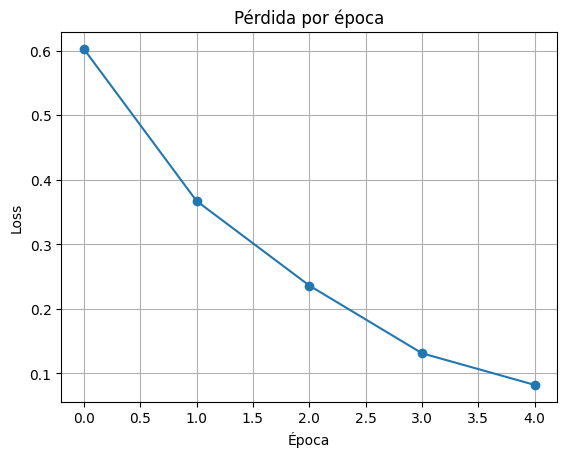

In [25]:
# Paso 5: Visualización de la pérdida
plt.plot(train_losses, marker='o')
plt.title('Pérdida por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Evaluación

In [26]:
model.eval()
preds, trues = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        preds.extend(predictions.cpu().numpy())
        trues.extend(labels.cpu().numpy())

# Clasificación
print(classification_report(trues, preds, digits=3))

              precision    recall  f1-score   support

           0      0.987     0.999     0.993      9101
           1      0.957     0.992     0.974      8426
           2      0.839     0.853     0.846      8357
           3      0.576     0.633     0.603     14043
           4      0.859     0.806     0.831     31414

    accuracy                          0.824     71341
   macro avg      0.844     0.856     0.849     71341
weighted avg      0.829     0.824     0.826     71341



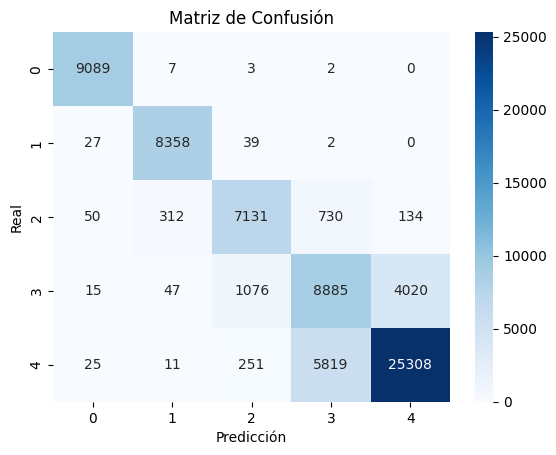

In [27]:
# Matriz de confusión
cm = confusion_matrix(trues, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [30]:
# Guardar los textos antes de perderlos en set_format()
texts_originales = processed["text"]


In [32]:
# Mostrar comparaciones correctas

correct = [(p, t, s) for p, t, s in zip(preds, trues, texts_originales) if p == t]

print("\nEjemplos de clasificaciones correctas:\n")
for p, t, s in correct[:200]:
    print(f"Texto: {s[:100]}...\nPredicho: {p} | Real: {t}\n")




Ejemplos de clasificaciones correctas:

Texto: el mejor lugar para comer sushi. excelente lugar para comer sushi! toda una experiencia que recomien...
Predicho: 0 | Real: 0

Texto: vista hermosa!. me sorprendió la maravillosa vista de la ciudad y sus montañas circundantes. el tren...
Predicho: 2 | Real: 2

Texto: desastroso. buenas noches,  ante todo explicar que he estado en este hotel en dos ocasiones, la prim...
Predicho: 3 | Real: 3

Texto: todo bien excepto que se niegan a dar vasos de agua. a pesar de ser restaurante que se jacta de tene...
Predicho: 1 | Real: 1

Texto: el mejor zoologico de méxico. el ambiente es muy agradable y sobre todo poder estar tan cerca de los...
Predicho: 2 | Real: 2

Texto: hermoso paseo a pie o en calesa. hermoso paseo para conocer las hermosas construcciones coloniales. ...
Predicho: 4 | Real: 4

Texto: excelente comida y buen servicio. el lugar es el indicado para ir a desayunar en pareja. se come muy...
Predicho: 2 | Real: 2

Texto: ideal para tod

In [33]:
# Mostrar comparaciones incorractas

wrong = [(p, t, s) for p, t, s in zip(preds, trues, texts_originales) if p != t]

print("\nEjemplos de errores de clasificación:\n")
for p, t, s in wrong[:200]:
    print(f"Texto: {s[:100]}...\nPredicho: {p} | Real: {t}\n")


Ejemplos de errores de clasificación:

Texto: muy buen hotel. muy bien hotel, con precio accesible. el cuarto está limpio aunque creo que faltó má...
Predicho: 4 | Real: 3

Texto: lugar increíble. no vayas con un tour organizado.. realmente recomiendo ir a este lugar, pero no con...
Predicho: 3 | Real: 4

Texto: gran comida justo ojalá nos hubiéramos quedado más tiempo. fuimos a los nardos para cenar la noche í...
Predicho: 4 | Real: 2

Texto: bello lugar. un plan que se debe realizar de vez en cuando!! teleferico, licor de hierbas, chocolate...
Predicho: 3 | Real: 4

Texto: simplemente increíble!. he visitado la ubicación en cholula varias veces. nunca me ha decepcionado.
...
Predicho: 4 | Real: 3

Texto: buena comida y ambiente.. este es un muy buen restaurante. fui con mi familia a comer. tienes que ha...
Predicho: 4 | Real: 3

Texto: arte... y no mas..... magnanima.... si te gusta el arte,  la arquitectura,  y  todo referente a cult...
Predicho: 3 | Real: 2

Texto: hermosa ciudad!

In [34]:
model.save_pretrained("modelo-turismo-sentimientos")
tokenizer.save_pretrained("modelo-turismo-sentimientos")

('modelo-turismo-sentimientos/tokenizer_config.json',
 'modelo-turismo-sentimientos/special_tokens_map.json',
 'modelo-turismo-sentimientos/vocab.json',
 'modelo-turismo-sentimientos/merges.txt',
 'modelo-turismo-sentimientos/added_tokens.json',
 'modelo-turismo-sentimientos/tokenizer.json')

# Comentarios finales:

Resumen del proceso:

* Se utilizó el dataset alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad, que contiene más de 250 mil ejemplos entre particiones train y test.

* Se realizó una combinación de ambas particiones para trabajar con todo el conjunto de datos.

* Se evidenció un fuerte desbalance de clases: la clase 5 tenía más de 150.000 registros, mientras que las clases 0 a 2 tenían menos de 22.000 entre las tres.

* Se aplicó una estrategia de oversampling moderado, añadiendo ejemplos sintéticos (réplicas) a las clases minoritarias para mejorar el aprendizaje del modelo.

* Se usó el modelo preentrenado PlanTL-GOB-ES/roberta-base-bne, entrenado en español, junto con un scheduler lineal y un learning rate ajustado a 1e-5.

Resultados obtenidos:

* La precisión global del modelo fue buena, especialmente en clases bien representadas (clases 3, 4 y 5).

* Se observaron errores comunes en las clases 0 y 1, que suelen confundirse con la clase 2.

* La visualización de la matriz de confusión y el análisis de errores permitieron identificar patrones de confusión, principalmente en textos neutros o ambiguos.